In [1]:
#a basic linear regression model built using pytorch
import torch
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(0)

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
#parameters:
w = 0.7 #ideal weight
b = 0 #ideal bias
X = torch.arange(0, 1, 0.02).unsqueeze(dim=1).to(device)
y = (w * X + b).to(device)

In [4]:
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]], device='cuda:0'),
 tensor([[0.0000],
         [0.0140],
         [0.0280],
         [0.0420],
         [0.0560],
         [0.0700],
         [0.0840],
         [0.0980],
         [0.1120],
         [0.1260]], device='cuda:0'))

In [5]:
len(X), len(y)

(50, 50)

In [6]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [7]:
def plot_graph(X_train, y_train, X_test, y_test, y_pred = None):    
    plt.scatter(X_train.to("cpu"), y_train.to("cpu").numpy(), c = "b", label = "train")
    plt.scatter(X_test.to("cpu"), y_test.to("cpu").numpy(), c="g", label = "test")
    if y_pred is not None:
        plt.scatter(X_test.to("cpu"), y_pred.detach().cpu().numpy(), label = "prediction")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.show()

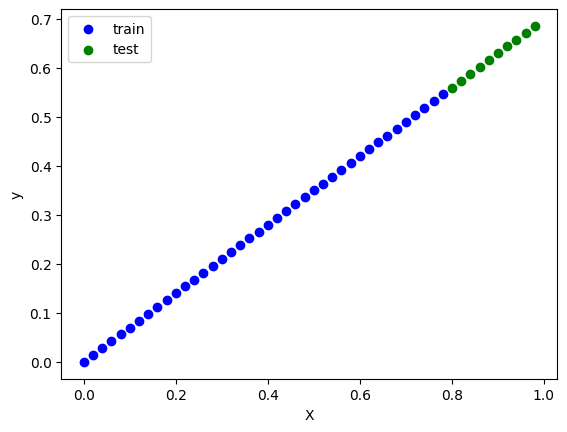

In [8]:
plot_graph(X_train, y_train, X_test, y_test)

In [9]:
from torch import nn

class LinearRegression(nn.Module): #nn.Module contains all the building block for the nn network
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float)) #by default requires_grad = True, which tells the autograd to keep track of the tensor
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    
    def forward(self, X):
        return self.weights * X + self.bias
    
    

In [10]:
torch.manual_seed(0)
linear_model = LinearRegression().to(device)
list(linear_model.parameters())

[Parameter containing:
 tensor([1.5410], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([-0.2934], device='cuda:0', requires_grad=True)]

In [11]:
linear_model.state_dict()

OrderedDict([('weights', tensor([1.5410], device='cuda:0')),
             ('bias', tensor([-0.2934], device='cuda:0'))])

In [12]:
#making predictions before training the model 
with torch.inference_mode(): #completely disables autograd, tensors created inside cannot be used in any gradient computation at all. Faster and uses less memory than no_grad()
    y_preds = linear_model(X_test)
    

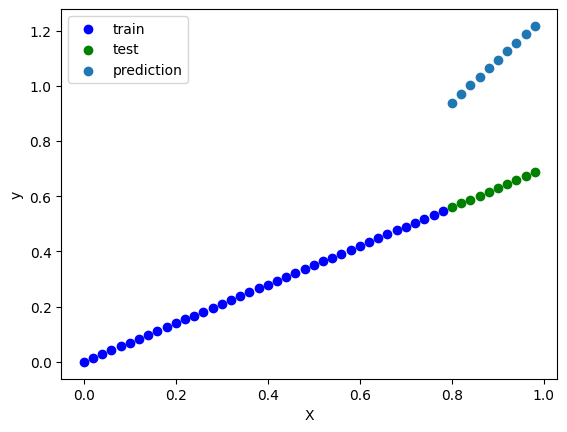

In [13]:
plot_graph(X_train, y_train, X_test, y_test, y_preds)

In [14]:
#define the loss function
loss_fn = nn.MSELoss()

#define the optimizer
optimizer = torch.optim.SGD(linear_model.parameters(), lr = 0.1)

#training loop
for epoch in range(100):
    linear_model.train()
    y_pred = linear_model(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad() #clear the previous grad, so that loss.backward replaces the previous grad
    loss.backward()
    optimizer.step() #this upgrades the weight
    linear_model.eval() #turns off the training mode, so that the model stops training behaviour like dropout and batchnorm
    print(loss.item())

0.03889208659529686
0.03719320520758629
0.0359300822019577
0.03492884337902069
0.034086793661117554
0.03334328159689903
0.03266240283846855
0.032022930681705475
0.03141222521662712
0.030822766944766045
0.03025003708899021
0.029691297560930252
0.029144857078790665
0.028609637171030045
0.02808493934571743
0.027570266276597977
0.02706526592373848
0.026569658890366554
0.02608320116996765
0.02560570277273655
0.025136975571513176
0.02467685006558895
0.024225154891610146
0.023781735450029373
0.02334643341600895
0.022919101640582085
0.02249959670007229
0.022087765857577324
0.021683473140001297
0.021286582574248314
0.02089695818722248
0.020514464005827904
0.020138969644904137
0.019770348444581032
0.01940847374498844
0.019053218886256218
0.018704473972320557
0.01836211420595646
0.018026014789938927
0.017696071416139603
0.017372166737914085
0.017054185271263123
0.016742026433348656
0.016435585916042328
0.01613474451005459
0.01583942025899887
0.015549498610198498
0.015264883637428284
0.01498547475

In [15]:
with torch.inference_mode():
    y_pred = linear_model(X_test)
print(loss_fn(y_pred, y_test).item()*100)

2.5101205334067345


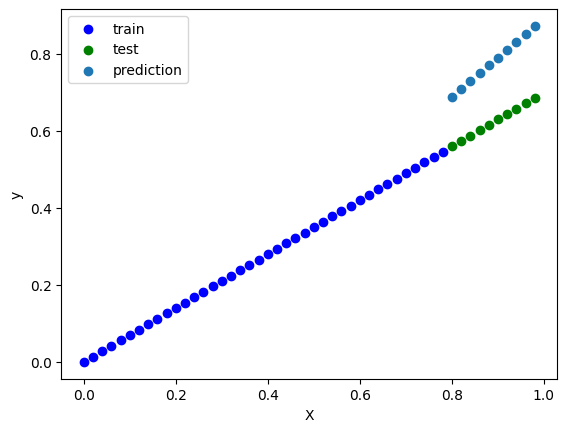

In [16]:
plot_graph(X_train, y_train, X_test, y_test, y_pred)

In [17]:
list(linear_model.parameters())

[Parameter containing:
 tensor([1.0269], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([-0.1336], device='cuda:0', requires_grad=True)]

In [18]:
torch.save(linear_model.state_dict(), "linear_model.pth") #this saves the state_dict of the model, which contains the parameters of the model, and can be used to load the model later
#load the parameters
# loaded_model = LinearRegression().to(device)
# loaded_model.load_state_dict(torch.load("linear_model.pth"))
# loaded_model.eval()
# with torch.inference_mode():
#     y_pred_loaded = loaded_model(X_test)
# plot_graph(X_train, y_train, X_test, y_test, y_pred_loaded)